# SF Climate Week — Year-over-Year Event Analysis

This notebook analyzes how the themes and types of events at SF Climate Week have evolved from 2023 to 2026, using the classified event data scraped from each year's program.

**Data:**  (2023–2026)  
**Key dimensions:** Event Type, Labels/Themes, Virtual vs. In-Person, Cost, City

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from collections import Counter

plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "sans-serif"
YEARS = [2023, 2024, 2025, 2026]
COLORS = ["#4C9A2A", "#2E86AB", "#E84855", "#F4A261"]

Matplotlib is building the font cache; this may take a moment.


In [3]:
# Load all years
dfs = {}
for yr in YEARS:
    df = pd.read_excel(f"sfcw_events_{yr}_classified.xlsx")
    df["Year"] = yr
    dfs[yr] = df

all_data = pd.concat(dfs.values(), ignore_index=True)

summary = pd.DataFrame({
    "Year": YEARS,
    "Total Events": [len(dfs[y]) for y in YEARS],
    "Unique Event Types": [dfs[y]["Event Type"].nunique() for y in YEARS],
    "In-Person": [dfs[y][dfs[y]["Virtual/In-Person"] == "In-Person"].shape[0] for y in YEARS],
    "Virtual": [dfs[y][dfs[y]["Virtual/In-Person"] == "Virtual"].shape[0] for y in YEARS],
    "Free Events": [dfs[y][dfs[y]["Cost"] == "Free"].shape[0] for y in YEARS],
})
summary.set_index("Year", inplace=True)
summary["YoY Growth"] = summary["Total Events"].pct_change().map(lambda x: f"{x:+.0%}" if pd.notna(x) else "—")
print(summary.to_string())

      Total Events  Unique Event Types  In-Person  Virtual  Free Events YoY Growth
Year                                                                              
2023           105                   9         62        4           36          —
2024           291                   9        185        4           97      +177%
2025           521                   8        310       13          181       +79%
2026           674                   8        611       38          580       +29%


---
## 1. Total Event Growth

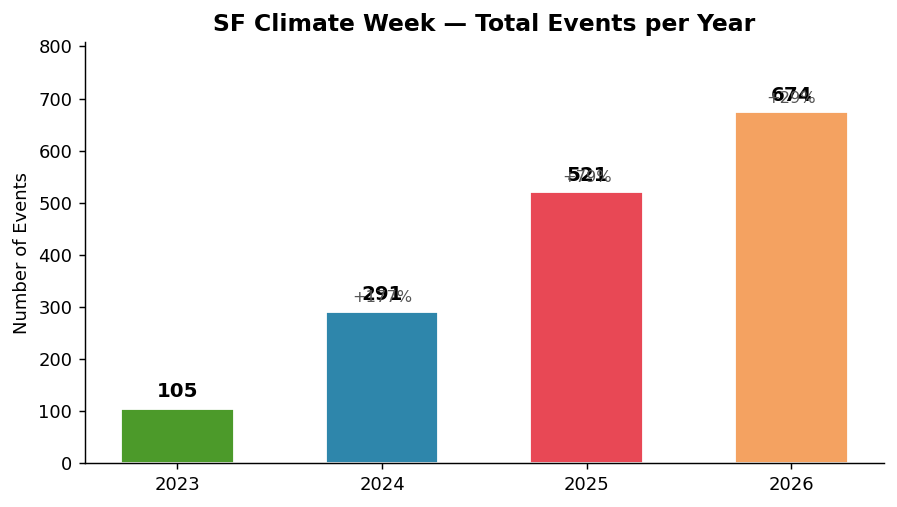


2023→2026 total growth: +542%  
(105 → 674 events)


In [8]:
counts = [len(dfs[y]) for y in YEARS]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(YEARS, counts, color=COLORS, width=0.55, edgecolor="white")
ax.bar_label(bars, labels=counts, padding=4, fontsize=11, fontweight="bold")

for i in range(1, len(YEARS)):
    growth = (counts[i] - counts[i-1]) / counts[i-1]
    ax.annotate(f"{growth:+.0%}", xy=(YEARS[i], counts[i] + 18),
                ha="center", fontsize=9, color="#555")

ax.set_title("SF Climate Week — Total Events per Year", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Events")
ax.set_xticks(YEARS)
ax.set_ylim(0, max(counts) * 1.2)
ax.yaxis.set_major_locator(mticker.MultipleLocator(100))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

total_growth = (counts[-1] - counts[0]) / counts[0]
print(f"\n2023→2026 total growth: {total_growth:+.0%}  \n({counts[0]} → {counts[-1]} events)")


---
## 2. Event Type Mix — Year over Year

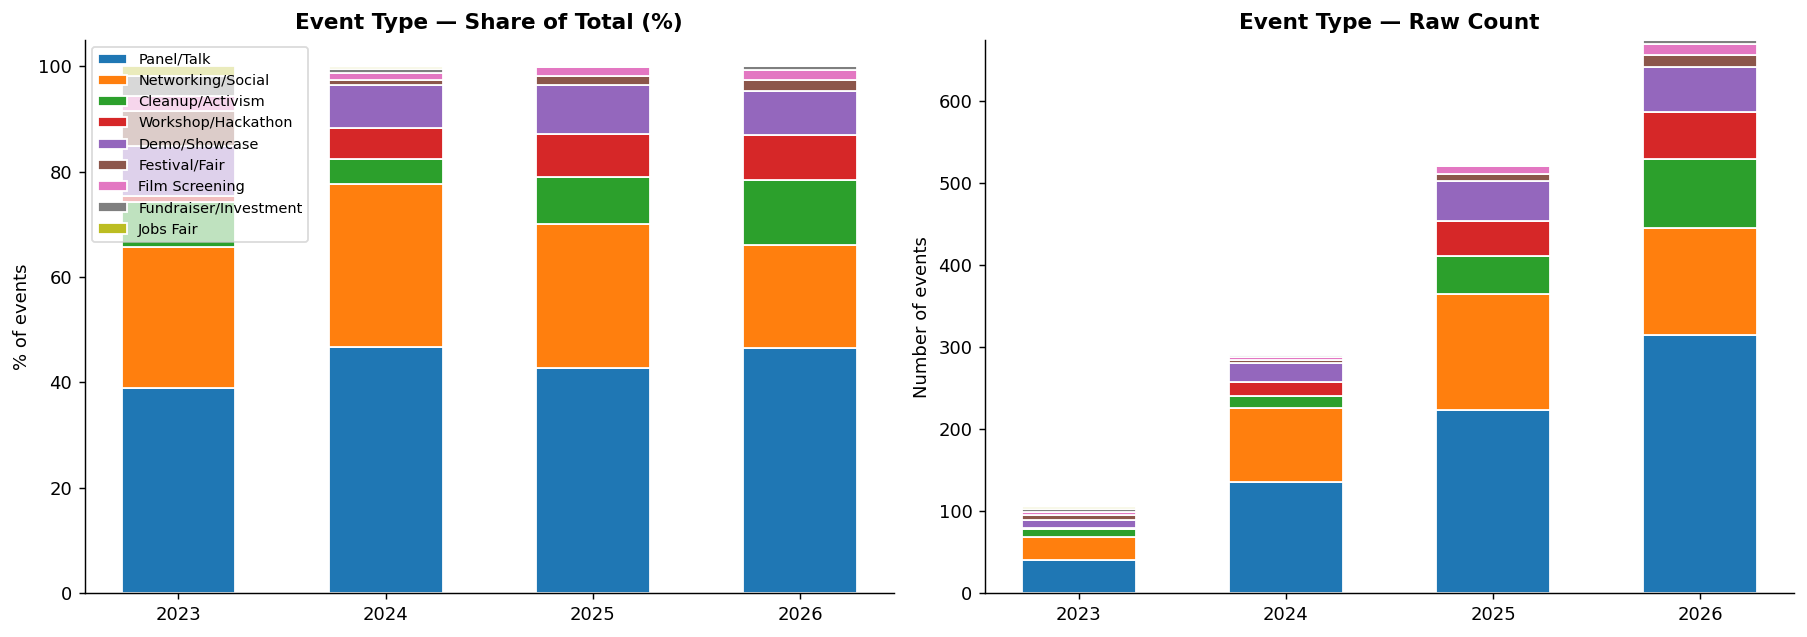


Raw counts by type:
Event Type  Panel/Talk  Networking/Social  Cleanup/Activism  Workshop/Hackathon  Demo/Showcase  Festival/Fair  Film Screening  Fundraiser/Investment  Jobs Fair
Year                                                                                                                                                           
2023                41                 28                 9                   1             10              7               3                      4          2
2024               136                 90                14                  17             24              3               4                      2          1
2025               223                142                46                  43             48              9               9                      0          1
2026               314                131                84                  57             55             15              13                      5          0


In [9]:
# Build event-type pivot (share of total)
type_pivot = pd.crosstab(
    all_data["Year"], all_data["Event Type"], normalize="index"
).mul(100).round(1)

type_order = type_pivot.loc[2026].sort_values(ascending=False).index.tolist()
type_pivot = type_pivot[type_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cmap = plt.get_cmap("tab10")
n_types = len(type_order)
type_colors = [cmap(i / n_types) for i in range(n_types)]

bottom = np.zeros(len(YEARS))
for i, etype in enumerate(type_order):
    vals = type_pivot[etype].values
    axes[0].bar(YEARS, vals, bottom=bottom, label=etype,
                color=type_colors[i], width=0.55, edgecolor="white")
    bottom += vals

axes[0].set_title("Event Type — Share of Total (%)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("% of events")
axes[0].set_xticks(YEARS)
axes[0].set_ylim(0, 105)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].legend(loc="upper left", fontsize=8, framealpha=0.7)

count_pivot = pd.crosstab(all_data["Year"], all_data["Event Type"])[type_order]
bottom = np.zeros(len(YEARS))
for i, etype in enumerate(type_order):
    vals = count_pivot[etype].values
    axes[1].bar(YEARS, vals, bottom=bottom, label=etype,
                color=type_colors[i], width=0.55, edgecolor="white")
    bottom += vals

axes[1].set_title("Event Type — Raw Count", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Number of events")
axes[1].set_xticks(YEARS)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("\nRaw counts by type:")
print(count_pivot.to_string())

### Key observations — Event Types

- **Panel/Talk** has been the dominant format every year and its absolute count has grown nearly 8× (41 → 314).
- **Networking/Social** roughly doubled in absolute terms but its *share* has shrunk, suggesting the week is becoming more content-dense.
- **Cleanup/Activism** has grown dramatically — from 9 events (2023) to 84 (2026) — suggesting a shift toward hands-on civic engagement.
- **Workshop/Hackathon** events were almost non-existent in 2023 (1 event) but have become a meaningful format by 2025–2026.
- **Demo/Showcase** counts have grown but its share has stayed roughly flat (~8%), keeping pace with the overall expansion.

---
## 3. Theme / Label Trends

In [10]:
def count_labels(df):
    counts = Counter()
    for val in df["Labels"].dropna():
        for label in str(val).split(","):
            counts[label.strip()] += 1
    return counts

label_counts = {yr: count_labels(dfs[yr]) for yr in YEARS}

all_top = set()
for yr in YEARS:
    all_top.update([k for k, _ in label_counts[yr].most_common(15)])

label_df = pd.DataFrame(
    {yr: {label: label_counts[yr].get(label, 0) / len(dfs[yr]) * 100
          for label in all_top} for yr in YEARS}
).T
label_df.index = YEARS
label_df = label_df[label_df.loc[2026].sort_values(ascending=False).index]

print("Label share (% of events in that year):")
print(label_df.round(1).to_string())

Label share (% of events in that year):
      Community  Cleantech  Nature/Biodiversity  Clean Energy  Climate Finance  Policy   AI  Water  ESG  Arts & Culture  Carbon Markets  Sustainability  Carbon Removal  Green Buildings  Decarbonization  Workforce/Talent  Food & Agriculture  Climate Justice  Hardware  Media  Youth/Education  Design
2023       27.6       37.1                  9.5           9.5             15.2     4.8  2.9    1.0  4.8             1.9             2.9             7.6             7.6              4.8              7.6               6.7                 3.8              3.8       7.6    1.9              4.8     4.8
2024       40.9       30.9                  9.3           8.6             18.9     9.6  6.2    3.4  4.8             1.7             3.1            10.0             8.6              3.4              3.8               5.5                 4.5              3.8       3.8    3.4              2.4     1.4
2025       51.2       23.2                 13.2          11.9  

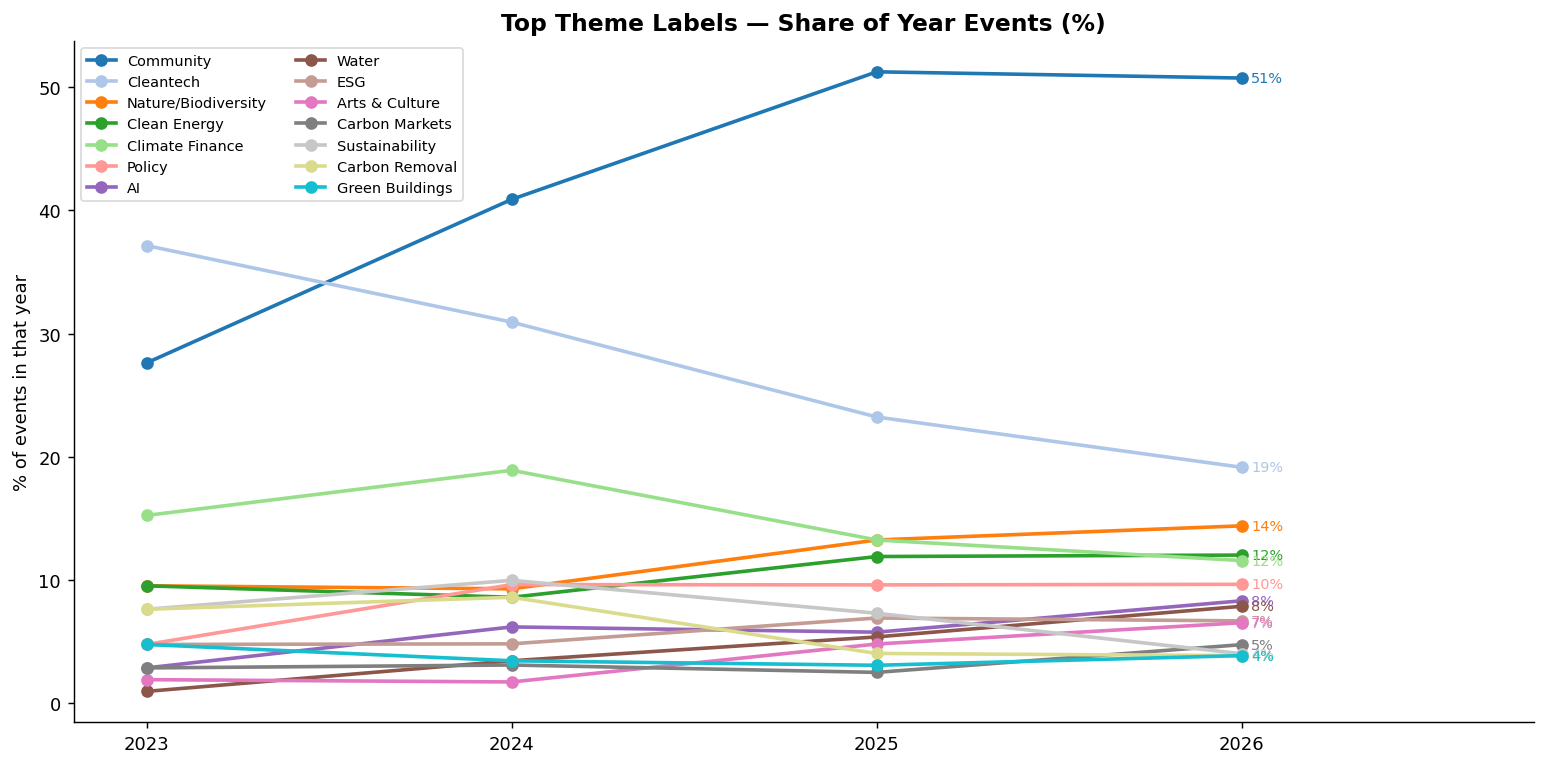

In [11]:
# Line chart: top 14 themes
top_labels = label_df.columns[:14].tolist()

fig, ax = plt.subplots(figsize=(12, 6))
cmap2 = plt.get_cmap("tab20")

for i, label in enumerate(top_labels):
    vals = label_df[label].values
    ax.plot(YEARS, vals, marker="o", label=label,
            color=cmap2(i / len(top_labels)), linewidth=2)
    ax.annotate(f"{vals[-1]:.0f}%", xy=(2026, vals[-1]),
                xytext=(5, 0), textcoords="offset points",
                va="center", fontsize=8, color=cmap2(i / len(top_labels)))

ax.set_title("Top Theme Labels — Share of Year Events (%)", fontsize=13, fontweight="bold")
ax.set_ylabel("% of events in that year")
ax.set_xticks(YEARS)
ax.set_xlim(2022.8, 2026.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", fontsize=8, ncol=2, framealpha=0.7)
plt.tight_layout()
plt.show()

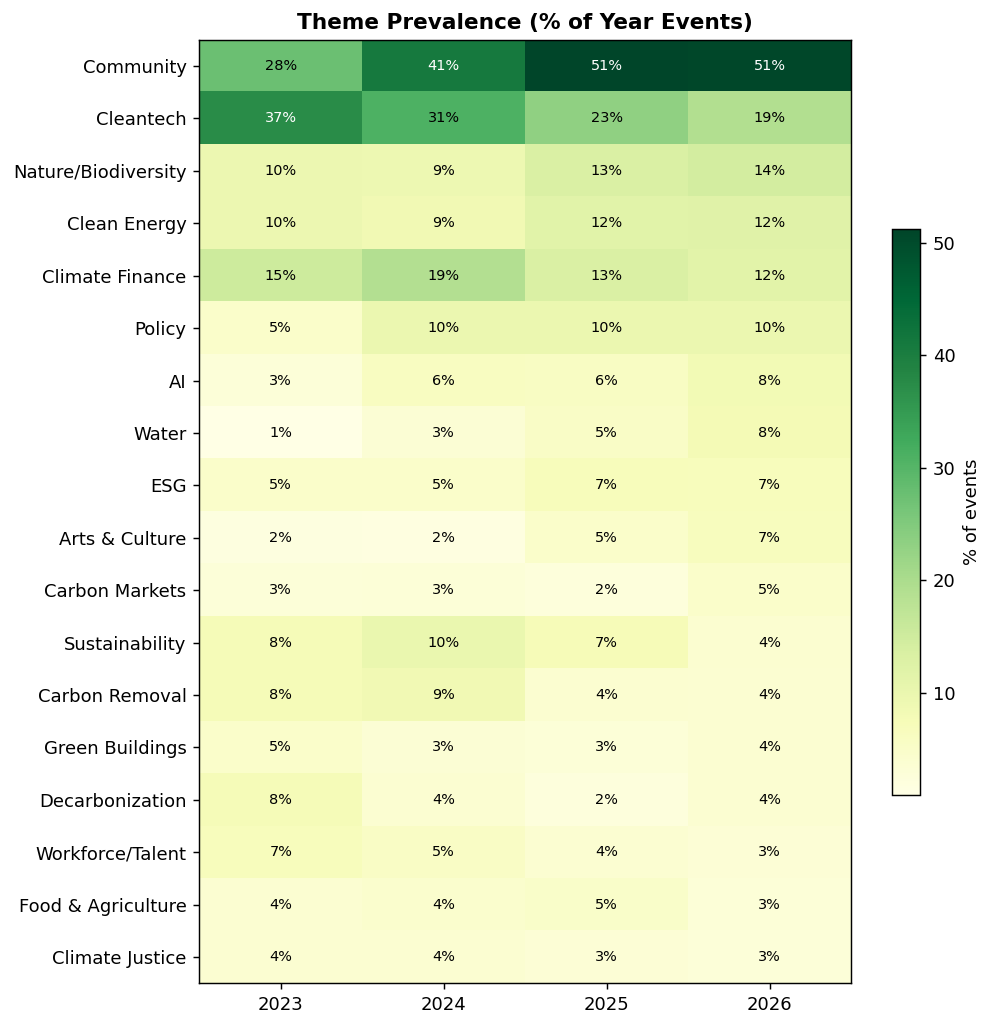

In [12]:
# Heatmap of label share
plot_labels = label_df.columns[:18]
heat_data = label_df[plot_labels].T

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(heat_data.values, aspect="auto", cmap="YlGn")

ax.set_xticks(range(len(YEARS)))
ax.set_xticklabels(YEARS)
ax.set_yticks(range(len(plot_labels)))
ax.set_yticklabels(plot_labels, fontsize=10)
ax.set_title("Theme Prevalence (% of Year Events)", fontsize=12, fontweight="bold")

for r in range(len(plot_labels)):
    for c in range(len(YEARS)):
        val = heat_data.values[r, c]
        ax.text(c, r, f"{val:.0f}%", ha="center", va="center",
                fontsize=8, color="black" if val < 35 else "white")

plt.colorbar(im, ax=ax, shrink=0.6, label="% of events")
plt.tight_layout()
plt.show()

### Key observations — Themes

| Theme | Trend |
|---|---|
| **Community** | Consistently the #1 label. Share grew from ~28% (2023) to ~51% (2026), signalling a move toward broad-tent, coalition-building events. |
| **Cleantech** | Dominant in 2023 (~37%), but *share* has declined as the event has broadened beyond startup/VC audiences. |
| **Climate Finance / ESG** | Strong in 2023–2024, holding steady in raw count but declining in share as other themes expand. |
| **Nature/Biodiversity** | Steadily rising in both share and count — barely present in 2023, now a top-4 theme. |
| **Water** | Near-absent in 2023; became significant by 2025–2026, likely reflecting California-specific policy focus. |
| **AI** | Appeared in 2024 (~6%), growing quickly through 2025–2026 (~8%), reflecting the AI-for-climate discourse. |
| **Arts & Culture** | Grew from negligible in 2023 to ~7% by 2026, consistent with the growth of Cleanup/Activism events. |
| **Carbon Markets** | Appeared as a distinct label in 2026 (previously folded into Carbon Removal), suggesting maturing market discourse. |

---
## 4. Rising & Falling Themes (2023 → 2026)

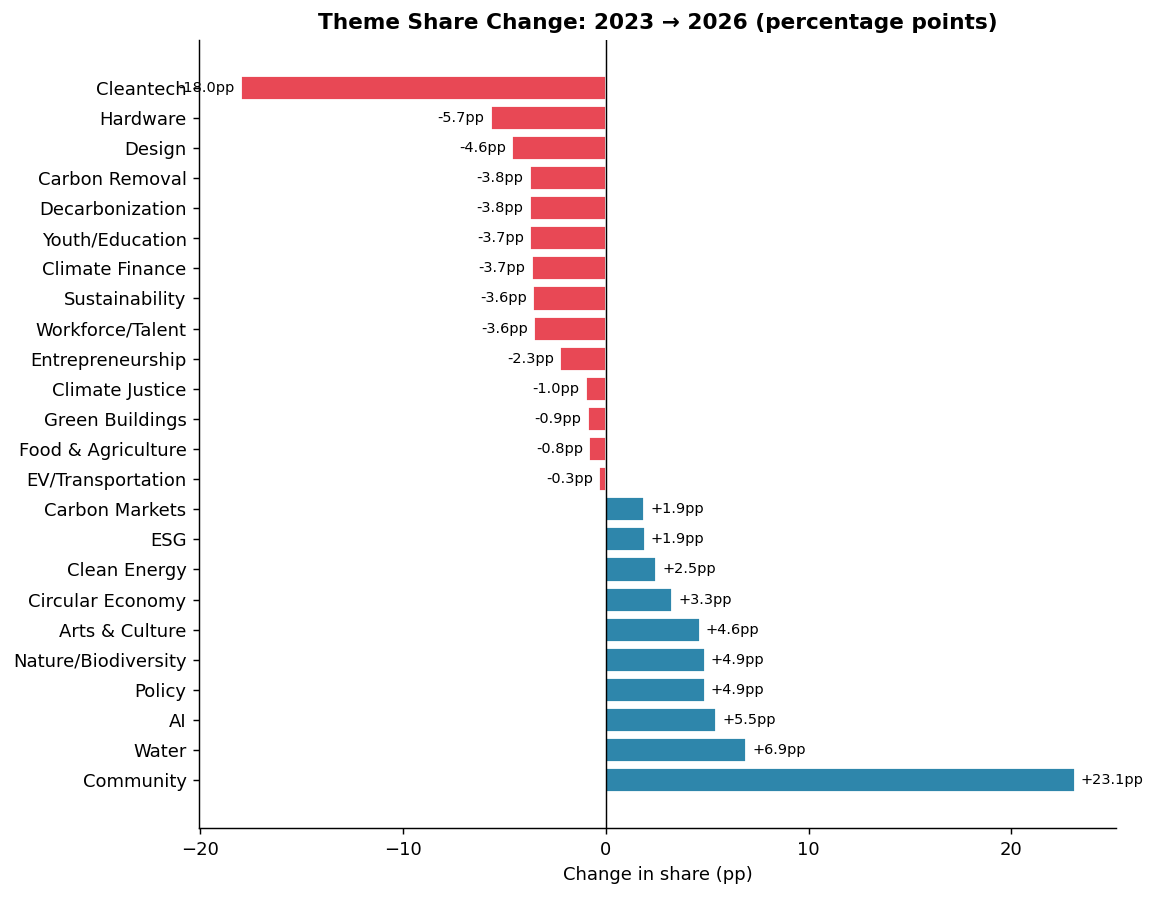

Top risers:
                     2023 Share  2026 Share  Change (pp)
Community             27.619048   50.741840    23.122792
Water                  0.952381    7.863501     6.911121
AI                     2.857143    8.308605     5.451462
Policy                 4.761905    9.643917     4.882012
Nature/Biodiversity    9.523810   14.391691     4.867882
Arts & Culture         1.904762    6.528190     4.623428
Circular Economy       0.000000    3.264095     3.264095
Clean Energy           9.523810   12.017804     2.493995
ESG                    4.761905    6.676558     1.914653
Carbon Markets         2.857143    4.747774     1.890632
Top fallers:
                    2023 Share  2026 Share  Change (pp)
EV/Transportation     2.857143    2.522255    -0.334888
Food & Agriculture    3.809524    2.967359    -0.842165
Green Buildings       4.761905    3.857567    -0.904338
Climate Justice       3.809524    2.818991    -0.990533
Entrepreneurship      2.857143    0.593472    -2.263671
Workforce/Ta

In [14]:
top_2023 = set(k for k, _ in label_counts[2023].most_common(20))
top_2026 = set(k for k, _ in label_counts[2026].most_common(20))
compare_labels = sorted(top_2023 | top_2026)

share_23 = {l: label_counts[2023].get(l, 0) / len(dfs[2023]) * 100 for l in compare_labels}
share_26 = {l: label_counts[2026].get(l, 0) / len(dfs[2026]) * 100 for l in compare_labels}

delta = pd.DataFrame({"2023 Share": share_23, "2026 Share": share_26})
delta["Change (pp)"] = delta["2026 Share"] - delta["2023 Share"]
delta = delta.sort_values("Change (pp)", ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
colors_bar = ["#2E86AB" if v >= 0 else "#E84855" for v in delta["Change (pp)"]]
bars = ax.barh(delta.index, delta["Change (pp)"], color=colors_bar, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)

for bar, val in zip(bars, delta["Change (pp)"]):
    xpos = bar.get_width() + (0.3 if val >= 0 else -0.3)
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f"{val:+.1f}pp", va="center", fontsize=8,
            ha="left" if val >= 0 else "right")

ax.set_title("Theme Share Change: 2023 → 2026 (percentage points)", fontsize=12, fontweight="bold")
ax.set_xlabel("Change in share (pp)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("Top risers:")
print(delta[delta["Change (pp)"] > 0].to_string())
print("Top fallers:")
print(delta[delta["Change (pp)"] < 0].to_string())

---
## 6. Cost / Accessibility

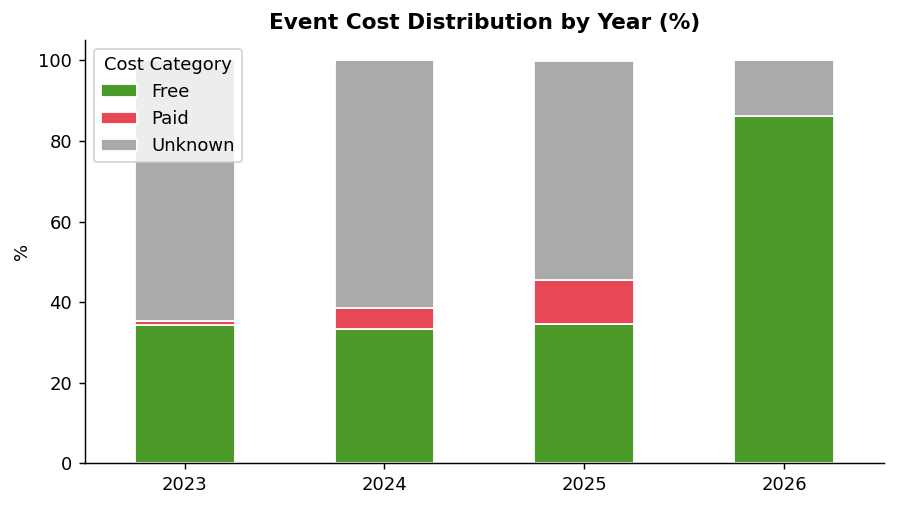

Cost Category  Free  Paid  Unknown
Year                              
2023             36     1       68
2024             97    15      179
2025            181    56      284
2026            580     0       94
Shares:
Cost Category  Free  Paid  Unknown
Year                              
2023           34.3   1.0     64.8
2024           33.3   5.2     61.5
2025           34.7  10.7     54.5
2026           86.1   0.0     13.9


In [18]:
def is_free(cost):
    if pd.isna(cost):
        return "Unknown"
    return "Free" if str(cost).strip().lower() == "free" else "Paid"

all_data["Cost Category"] = all_data["Cost"].apply(is_free)
cost_pivot = pd.crosstab(all_data["Year"], all_data["Cost Category"])
cost_pct = cost_pivot.div(cost_pivot.sum(axis=1), axis=0).mul(100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
cols_to_plot = [c for c in ["Free", "Paid", "Unknown"] if c in cost_pct.columns]
cost_pct[cols_to_plot].plot(
    kind="bar", stacked=True, ax=ax,
    color=["#4C9A2A", "#E84855", "#aaa"][:len(cols_to_plot)], edgecolor="white", rot=0)
ax.set_title("Event Cost Distribution by Year (%)", fontsize=12, fontweight="bold")
ax.set_ylabel("%")
ax.set_xlabel("")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(cost_pivot)
print("Shares:")
print(cost_pct)

---
## 8. Summary: Key Narratives 2023 → 2026

### Scale
SF Climate Week has grown **~6.4× in total events** (105 → 674), becoming one of the largest climate convenings in North America.

### Format evolution
- **Panels/Talks** dominate every year but workshops and activism events have gained ground, suggesting the week is getting more participatory.
- **Virtual events** remain a tiny fraction (<6%); the week is overwhelmingly in-person.

### Thematic shifts
| Direction | Themes |
|---|---|
| Strongly rising | Community, Nature/Biodiversity, Water, AI, Arts & Culture |
| Holding steady | Climate Finance, Clean Energy, Policy, ESG |
| Declining in share | Cleantech (still #2 in raw count, but less dominant), Hardware, Workforce/Talent |
| Newly prominent | Carbon Markets (2026 label split), Mental Health, Circular Economy |

### Broader interpretation
The week started as a **startup & investor-heavy** event (Cleantech, Hardware, Climate Finance dominating), but has shifted toward a **coalition-building civic event** (Community, Nature/Biodiversity, Water, Arts & Culture) while still retaining its finance/policy core. The rise of AI as a label tracks the broader industry narrative. The explosion of Cleanup/Activism events and the new Carbon Markets label reflect both grassroots growth and maturing market infrastructure.